In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [12]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

print("Training set shape:", df_train.shape)
print("Test set shape:", df_test.shape)
print("*********************************************")
print("Training set columns:", df_train.columns)
print("Test set columns:", df_test.columns)

Training set shape: (8068, 11)
Test set shape: (2627, 11)
*********************************************
Training set columns: Index(['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1',
       'Segmentation'],
      dtype='object')
Test set columns: Index(['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1',
       'Segmentation'],
      dtype='object')


## Exploring Data & Remove outliers

In [13]:
df_train.info()
print("*********************************************")
print("Missing values in training set:\n", df_train.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB
*********************************************
Missing values in training set:
 ID                   0
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experienc

In [14]:
df_test.info()
print("*********************************************")
print("Missing values in test set:\n", df_test.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               2627 non-null   int64  
 1   Gender           2627 non-null   object 
 2   Ever_Married     2577 non-null   object 
 3   Age              2627 non-null   int64  
 4   Graduated        2603 non-null   object 
 5   Profession       2589 non-null   object 
 6   Work_Experience  2358 non-null   float64
 7   Spending_Score   2627 non-null   object 
 8   Family_Size      2514 non-null   float64
 9   Var_1            2595 non-null   object 
 10  Segmentation     2627 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 225.9+ KB
*********************************************
Missing values in test set:
 ID                   0
Gender               0
Ever_Married        50
Age                  0
Graduated           24
Profession          38
Work_Experience   

In [15]:
df_train.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [16]:
df_train.drop('ID', axis=1, inplace=True)


In [17]:
df_train

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A
...,...,...,...,...,...,...,...,...,...,...
8063,Male,No,22,No,NaN,0.0,Low,7.0,Cat_1,D
8064,Male,No,35,No,Executive,3.0,Low,4.0,Cat_4,D
8065,Female,No,33,Yes,Healthcare,1.0,Low,1.0,Cat_6,D
8066,Female,No,27,Yes,Healthcare,1.0,Low,4.0,Cat_6,B


<Axes: xlabel='Segmentation', ylabel='Age'>

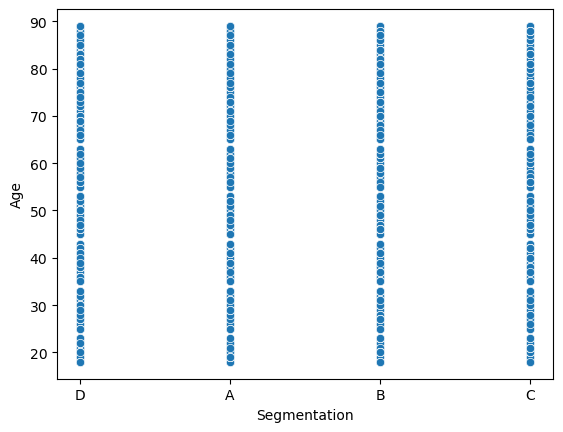

In [18]:
sns.scatterplot( y = 'Age', x = 'Segmentation', data = df_train )

C:\Users\Admin\AppData\Local\Temp\ipykernel_16968\1965003454.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


[Text(0, 0, '18'),
 Text(1, 0, '19'),
 Text(2, 0, '20'),
 Text(3, 0, '21'),
 Text(4, 0, '22'),
 Text(5, 0, '23'),
 Text(6, 0, '25'),
 Text(7, 0, '26'),
 Text(8, 0, '27'),
 Text(9, 0, '28'),
 Text(10, 0, '29'),
 Text(11, 0, '30'),
 Text(12, 0, '31'),
 Text(13, 0, '32'),
 Text(14, 0, '33'),
 Text(15, 0, '35'),
 Text(16, 0, '36'),
 Text(17, 0, '37'),
 Text(18, 0, '38'),
 Text(19, 0, '39'),
 Text(20, 0, '40'),
 Text(21, 0, '41'),
 Text(22, 0, '42'),
 Text(23, 0, '43'),
 Text(24, 0, '45'),
 Text(25, 0, '46'),
 Text(26, 0, '47'),
 Text(27, 0, '48'),
 Text(28, 0, '49'),
 Text(29, 0, '50'),
 Text(30, 0, '51'),
 Text(31, 0, '52'),
 Text(32, 0, '53'),
 Text(33, 0, '55'),
 Text(34, 0, '56'),
 Text(35, 0, '57'),
 Text(36, 0, '58'),
 Text(37, 0, '59'),
 Text(38, 0, '60'),
 Text(39, 0, '61'),
 Text(40, 0, '62'),
 Text(41, 0, '63'),
 Text(42, 0, '65'),
 Text(43, 0, '66'),
 Text(44, 0, '67'),
 Text(45, 0, '68'),
 Text(46, 0, '69'),
 Text(47, 0, '70'),
 Text(48, 0, '71'),
 Text(49, 0, '72'),
 Text(50, 

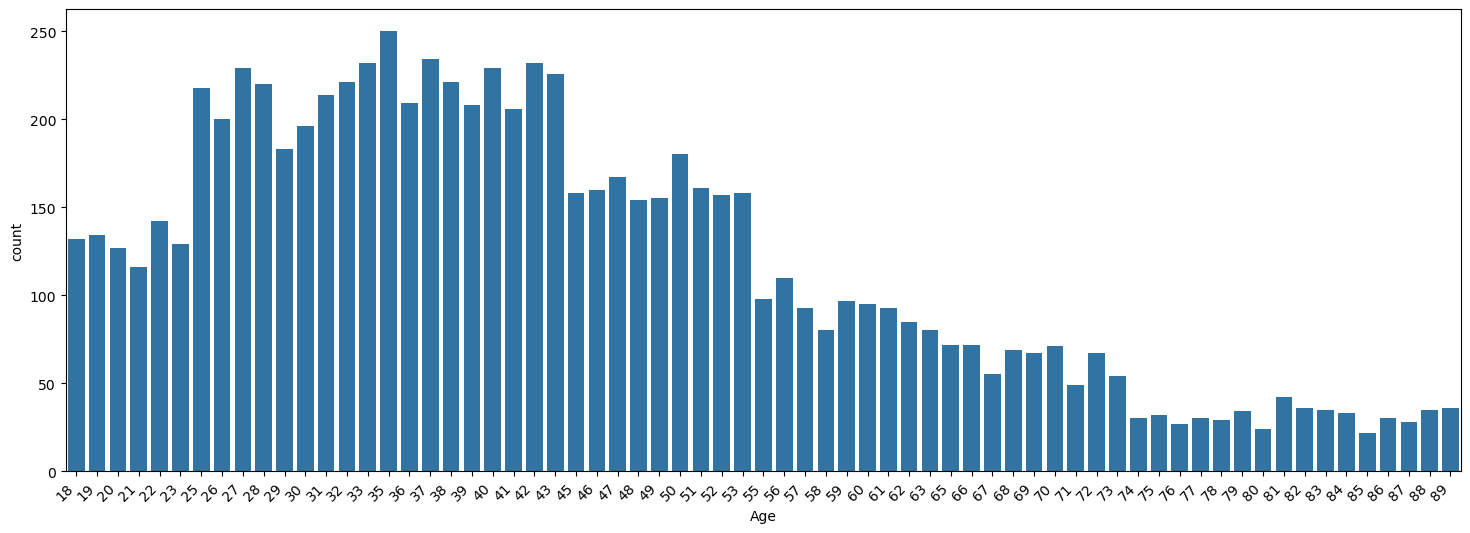

In [19]:
plt.figure(figsize=(18,6))
ax = sns.countplot(x="Age", data=df_train)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

<Axes: xlabel='Segmentation', ylabel='Work_Experience'>

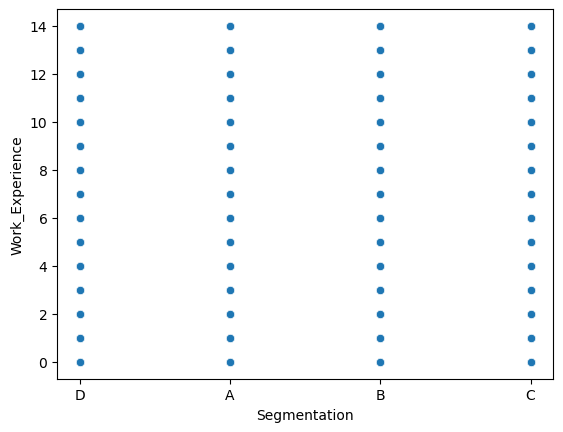

In [20]:
sns.scatterplot( y = 'Work_Experience', x = 'Segmentation', data = df_train )

C:\Users\Admin\AppData\Local\Temp\ipykernel_16968\317642588.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


[Text(0, 0, '0.0'),
 Text(1, 0, '1.0'),
 Text(2, 0, '2.0'),
 Text(3, 0, '3.0'),
 Text(4, 0, '4.0'),
 Text(5, 0, '5.0'),
 Text(6, 0, '6.0'),
 Text(7, 0, '7.0'),
 Text(8, 0, '8.0'),
 Text(9, 0, '9.0'),
 Text(10, 0, '10.0'),
 Text(11, 0, '11.0'),
 Text(12, 0, '12.0'),
 Text(13, 0, '13.0'),
 Text(14, 0, '14.0')]

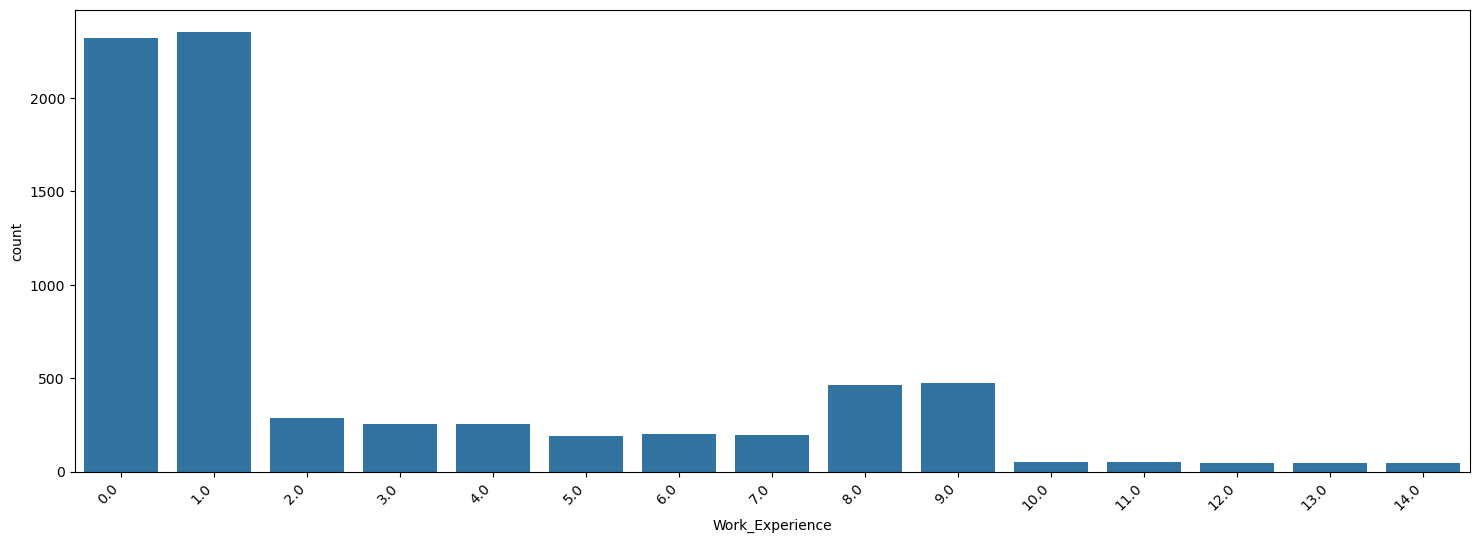

In [21]:
plt.figure(figsize=(18,6))
ax = sns.countplot(x="Work_Experience", data=df_train)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

In [22]:
df_train['Work_Experience'].skew()

np.float64(1.3062257604935081)

In [23]:
def remove_outliers_iqr(data, column_name="value"):
    Q1 = df_train[column_name].quantile(0.25)
    Q3 = df_train[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 *IQR
    upper = Q3 + 1.5 *IQR
    return df_train[(df_train[column_name] >= lower) & (df_train[column_name] <= upper)]

l=['Work_Experience']
for col in l:
    df_train = remove_outliers_iqr(df_train, column_name=col)

print(df_train.shape)

(7050, 10)


In [24]:
df_train['Work_Experience'].skew()

np.float64(1.2120691666219914)

C:\Users\Admin\AppData\Local\Temp\ipykernel_16968\2639401609.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


[Text(0, 0, '1.0'),
 Text(1, 0, '2.0'),
 Text(2, 0, '3.0'),
 Text(3, 0, '4.0'),
 Text(4, 0, '5.0'),
 Text(5, 0, '6.0'),
 Text(6, 0, '7.0'),
 Text(7, 0, '8.0'),
 Text(8, 0, '9.0')]

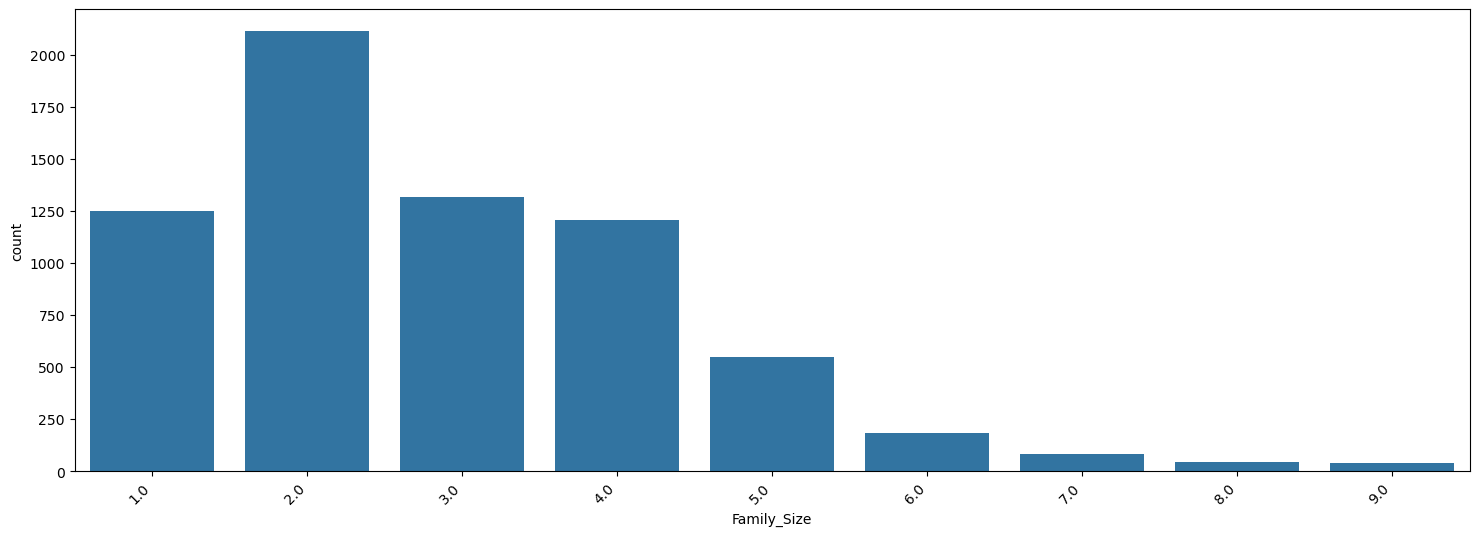

In [25]:
plt.figure(figsize=(18,6))
ax = sns.countplot(x="Family_Size", data=df_train)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

In [26]:
df_train['Family_Size'].skew()

np.float64(1.0002077080251237)

In [27]:
l=['Family_Size']
for col in l:
    df_train = remove_outliers_iqr(df_train, column_name=col)

print(df_train.shape)

(6708, 10)


In [28]:
df_train.isna().sum().sort_values(ascending=False)

Ever_Married       103
Profession          89
Graduated           58
Var_1               55
Gender               0
Age                  0
Work_Experience      0
Spending_Score       0
Family_Size          0
Segmentation         0
dtype: int64

In [29]:
for col in df_train.columns:
    print(col,df_train[col].dtype)
    print(col,df_train[col].unique())
    print('-'*35)

Gender object
Gender ['Male' 'Female']
-----------------------------------
Ever_Married object
Ever_Married ['No' 'Yes' nan]
-----------------------------------
Age int64
Age [22 67 56 32 33 61 55 26 19 58 41 31 79 18 36 49 35 45 42 83 27 28 47 40
 57 76 25 48 74 59 51 30 63 52 39 38 60 68 86 43 80 37 46 72 69 50 29 71
 78 82 70 20 21 53 23 85 62 75 65 89 66 73 77 87 84 88 81]
-----------------------------------
Graduated object
Graduated ['No' 'Yes' nan]
-----------------------------------
Profession object
Profession ['Healthcare' 'Engineer' 'Lawyer' 'Artist' 'Doctor' 'Homemaker'
 'Entertainment' 'Executive' 'Marketing' nan]
-----------------------------------
Work_Experience float64
Work_Experience [ 1.  0.  4.  9.  3.  5.  8.  7.  2.  6. 10.]
-----------------------------------
Spending_Score object
Spending_Score ['Low' 'High' 'Average']
-----------------------------------
Family_Size float64
Family_Size [4. 1. 2. 3. 5. 6. 7.]
-----------------------------------
Var_1 object
Var_1

In [30]:
for col in df_test.columns:
    print(col,df_test[col].dtype)
    print(col,df_test[col].unique())
    print('-'*35)

ID int64
ID [458989 458994 458996 ... 467960 467961 467968]
-----------------------------------
Gender object
Gender ['Female' 'Male']
-----------------------------------
Ever_Married object
Ever_Married ['Yes' 'No' nan]
-----------------------------------
Age int64
Age [36 37 69 59 19 47 61 50 22 27 18 20 45 55 88 63 42 79 35 52 29 87 89 31
 72 41 62 56 60 68 57 51 86 74 23 80 78 48 70 83 73 46 43 32 39 71 67 49
 65 33 58 30 21 26 81 28 76 85 66 53 40 25 77 75 82 84 38]
-----------------------------------
Graduated object
Graduated ['Yes' 'No' nan]
-----------------------------------
Profession object
Profession ['Engineer' 'Healthcare' nan 'Executive' 'Marketing' 'Doctor' 'Artist'
 'Lawyer' 'Entertainment' 'Homemaker']
-----------------------------------
Work_Experience float64
Work_Experience [ 0.  8. 11. nan  5.  1.  2.  9.  3.  6.  7.  4. 13. 10. 12. 14.]
-----------------------------------
Spending_Score object
Spending_Score ['Low' 'Average' 'High']
-----------------------------

### Handling NaN Values

In [31]:
from sklearn.impute import SimpleImputer

everMaried = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

df_train[['Ever_Married']] = everMaried.fit_transform(df_train[['Ever_Married']])
df_test[['Ever_Married']] = everMaried.transform(df_test[['Ever_Married']])

In [32]:
df_train['Ever_Married'].unique()


array(['No', 'Yes'], dtype=object)

In [33]:
df_test['Ever_Married'].unique()

array(['Yes', 'No'], dtype=object)

In [34]:
everGraduated = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

df_train[['Graduated']] = everGraduated.fit_transform(df_train[['Graduated']])
df_test[['Graduated']] = everGraduated.transform(df_test[['Graduated']])

In [35]:
imputer_profession = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

df_train[['Profession']] = imputer_profession.fit_transform(df_train[['Profession']])

df_test[['Profession']] = imputer_profession.transform(df_test[['Profession']])

In [36]:
df_train['Profession'].unique()

array(['Healthcare', 'Engineer', 'Lawyer', 'Artist', 'Doctor',
       'Homemaker', 'Entertainment', 'Executive', 'Marketing'],
      dtype=object)

In [37]:
df_train = df_train.dropna(subset=['Var_1'],axis=0)
df_test = df_test.dropna(subset=['Var_1'],axis=0)

In [38]:
df_train['Var_1'].unique()

array(['Cat_4', 'Cat_6', 'Cat_7', 'Cat_3', 'Cat_1', 'Cat_2', 'Cat_5'],
      dtype=object)

In [39]:
df_test['Var_1'].unique()

array(['Cat_6', 'Cat_4', 'Cat_3', 'Cat_1', 'Cat_2', 'Cat_5', 'Cat_7'],
      dtype=object)

In [40]:
df_train.isna().sum().sort_values(ascending=False)

Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
Segmentation       0
dtype: int64

In [41]:
df_test.isna().sum().sort_values(ascending=False)

Work_Experience    264
Family_Size        108
ID                   0
Ever_Married         0
Gender               0
Graduated            0
Age                  0
Profession           0
Spending_Score       0
Var_1                0
Segmentation         0
dtype: int64

In [42]:
df_test = df_test.dropna(subset =['Work_Experience','Family_Size'])

In [43]:
df_test.isna().sum().sort_values(ascending=False)

ID                 0
Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
Segmentation       0
dtype: int64

In [44]:
df_test.shape

(2243, 11)

In [45]:
df_train.drop_duplicates()


,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
5,Male,Yes,56,No,Artist,0.0,Average,2.0,Cat_6,C
6,Male,No,32,Yes,Healthcare,1.0,Low,3.0,Cat_6,C
...,...,...,...,...,...,...,...,...,...,...
8062,Male,Yes,41,Yes,Artist,0.0,High,5.0,Cat_6,B
8063,Male,No,22,No,Artist,0.0,Low,7.0,Cat_1,D
8064,Male,No,35,No,Executive,3.0,Low,4.0,Cat_4,D
8066,Female,No,27,Yes,Healthcare,1.0,Low,4.0,Cat_6,B


In [46]:
df_train.reset_index(inplace=True)

In [47]:
df_test.drop_duplicates()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6,B
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6,A
2,458996,Female,Yes,69,No,Artist,0.0,Low,1.0,Cat_6,A
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6,B
5,459003,Male,Yes,47,Yes,Doctor,0.0,High,5.0,Cat_4,C
...,...,...,...,...,...,...,...,...,...,...,...
2621,467950,Female,No,35,Yes,Entertainment,1.0,Low,2.0,Cat_6,D
2622,467954,Male,No,29,No,Healthcare,9.0,Low,4.0,Cat_6,B
2623,467958,Female,No,35,Yes,Doctor,1.0,Low,1.0,Cat_6,A
2625,467961,Male,Yes,47,Yes,Executive,1.0,High,5.0,Cat_4,C


In [48]:
df_test.reset_index(inplace=True)

## Visualization

C:\Users\Admin\AppData\Local\Temp\ipykernel_16968\3069528337.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


[Text(0, 0, 'Healthcare'),
 Text(1, 0, 'Engineer'),
 Text(2, 0, 'Lawyer'),
 Text(3, 0, 'Artist'),
 Text(4, 0, 'Doctor'),
 Text(5, 0, 'Homemaker'),
 Text(6, 0, 'Entertainment'),
 Text(7, 0, 'Executive'),
 Text(8, 0, 'Marketing')]

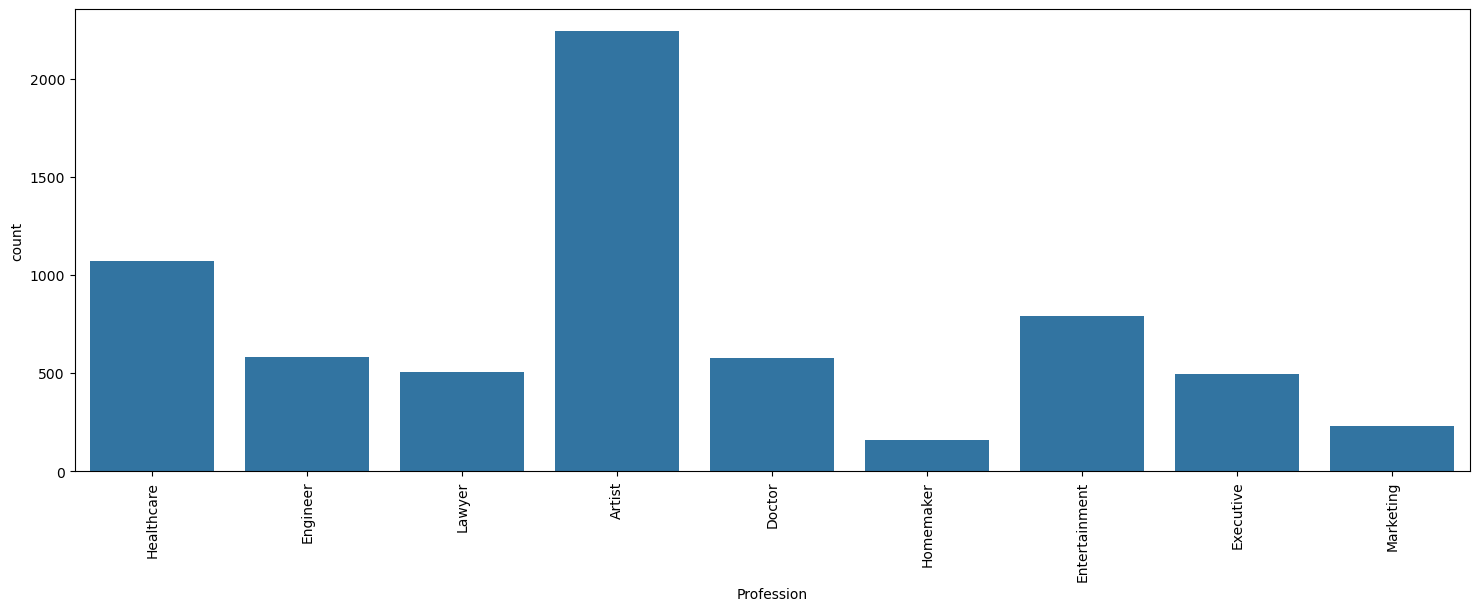

In [49]:
plt.figure(figsize=(18,6))

ax = sns.countplot(data=df_train,x='Profession')

ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

C:\Users\Admin\AppData\Local\Temp\ipykernel_16968\39274222.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


[Text(0, 0, '0.0'),
 Text(1, 0, '1.0'),
 Text(2, 0, '2.0'),
 Text(3, 0, '3.0'),
 Text(4, 0, '4.0'),
 Text(5, 0, '5.0'),
 Text(6, 0, '6.0'),
 Text(7, 0, '7.0'),
 Text(8, 0, '8.0'),
 Text(9, 0, '9.0'),
 Text(10, 0, '10.0')]

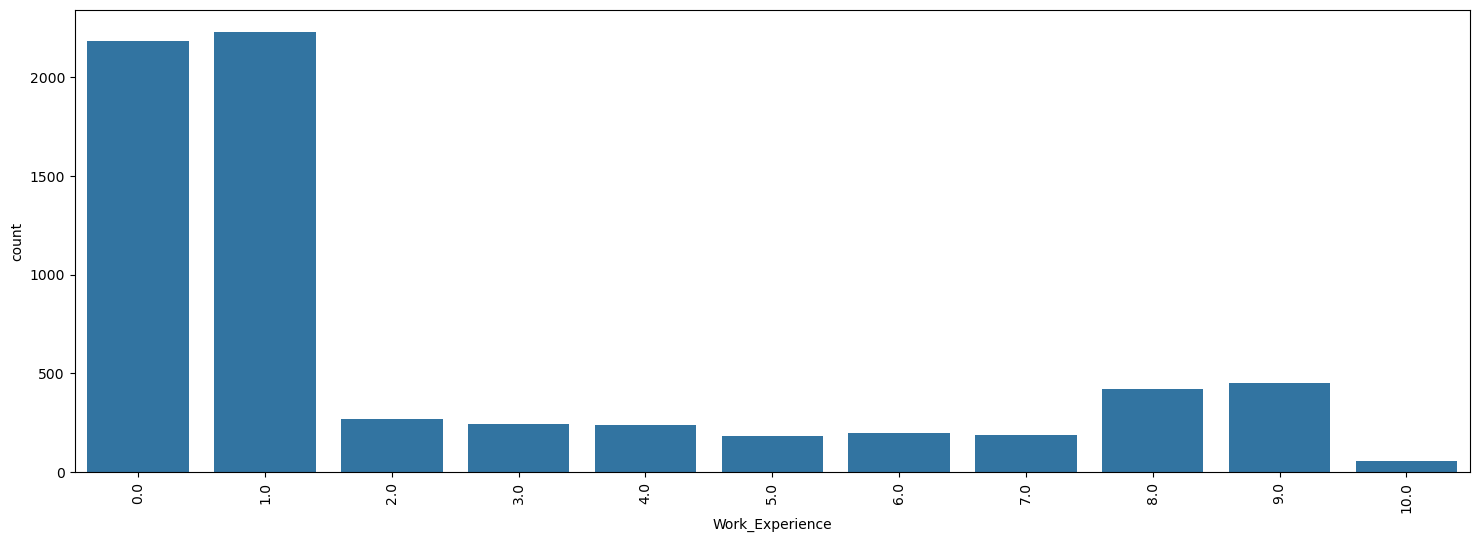

In [50]:
plt.figure(figsize=(18,6))

ax = sns.countplot(data=df_train,x='Work_Experience')

ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

C:\Users\Admin\AppData\Local\Temp\ipykernel_16968\1700614296.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


[Text(0, 0, '1.0'),
 Text(1, 0, '2.0'),
 Text(2, 0, '3.0'),
 Text(3, 0, '4.0'),
 Text(4, 0, '5.0'),
 Text(5, 0, '6.0'),
 Text(6, 0, '7.0')]

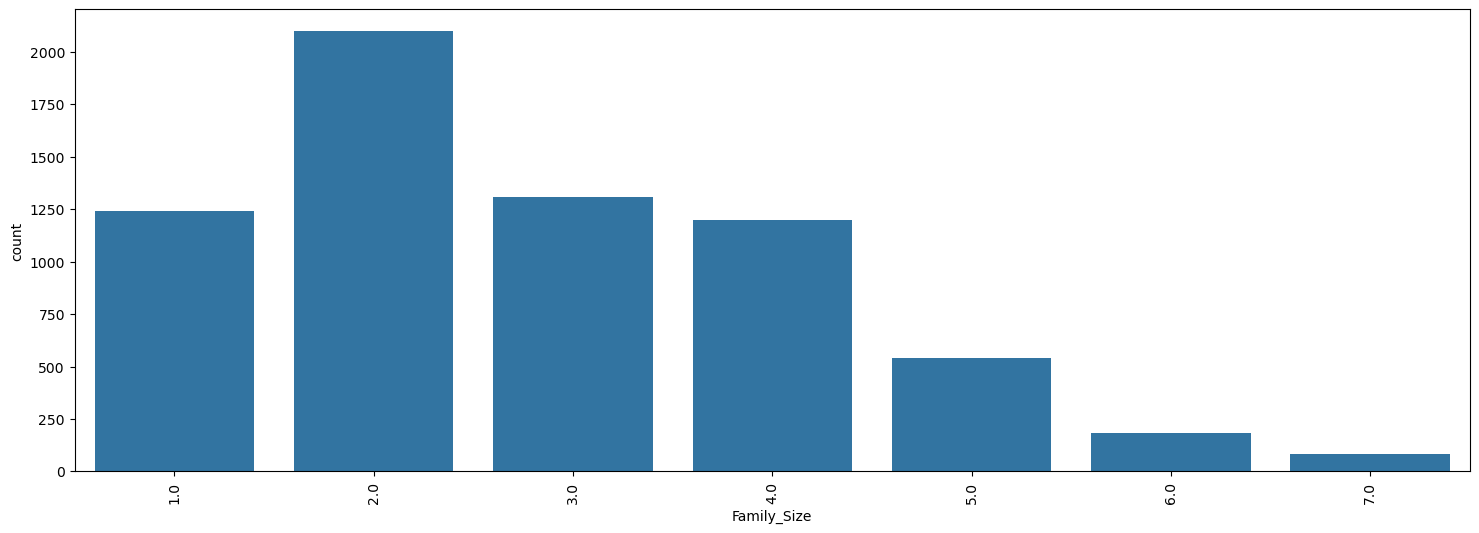

In [51]:
plt.figure(figsize=(18,6))

ax = sns.countplot(data=df_train,x='Family_Size')

ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

C:\Users\Admin\AppData\Local\Temp\ipykernel_16968\3725170252.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


[Text(0, 0, 'Low'), Text(1, 0, 'High'), Text(2, 0, 'Average')]

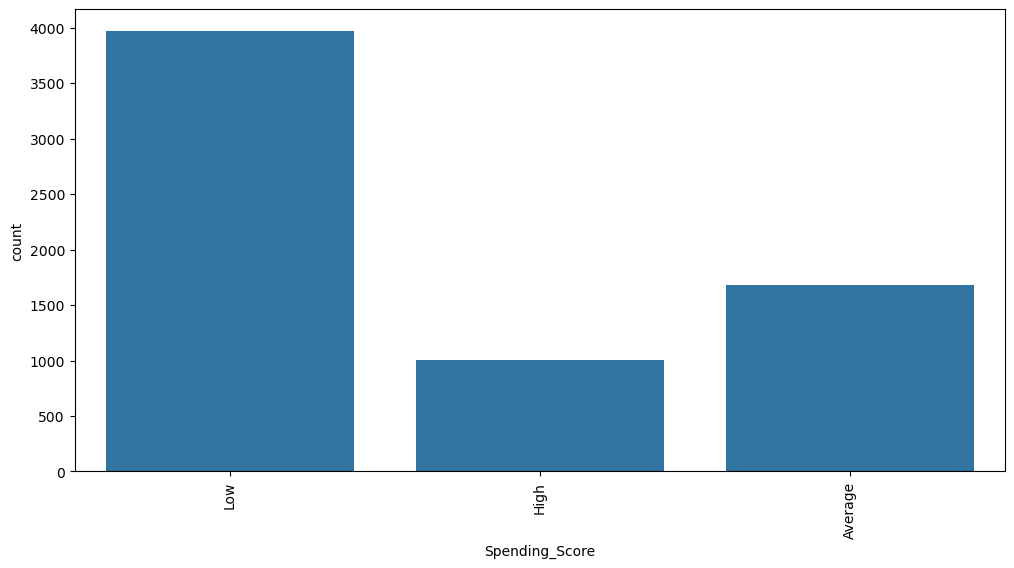

In [52]:
plt.figure(figsize=(12,6))

ax = sns.countplot(data=df_train,x='Spending_Score')

ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

C:\Users\Admin\AppData\Local\Temp\ipykernel_16968\173755194.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


[Text(0, 0, 'No'), Text(1, 0, 'Yes')]

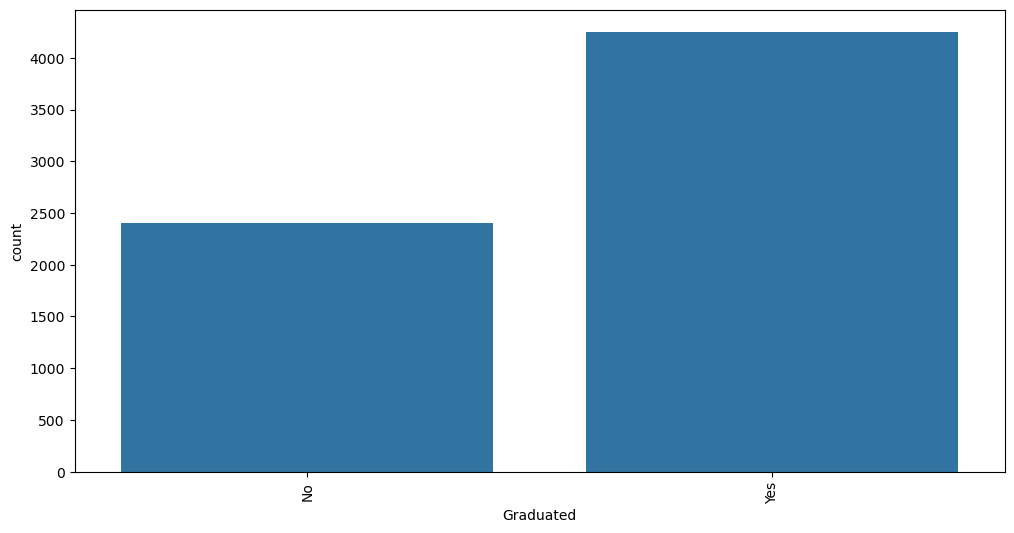

In [53]:
plt.figure(figsize=(12,6))

ax = sns.countplot(data=df_train,x='Graduated')

ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

## Encoding

In [55]:
for col in df_train.columns:
    print(col,df_train[col].dtype)
    print(col,df_train[col].unique())
    print('-'*35)

index int64
index [   0    2    3 ... 8065 8066 8067]
-----------------------------------
Gender object
Gender ['Male' 'Female']
-----------------------------------
Ever_Married object
Ever_Married ['No' 'Yes']
-----------------------------------
Age int64
Age [22 67 56 32 33 61 55 26 19 58 41 31 79 18 36 49 35 45 42 83 27 28 47 40
 57 76 25 48 74 59 51 30 63 52 39 38 60 68 86 43 80 37 46 72 69 50 29 71
 78 82 70 20 21 53 23 85 62 75 65 89 66 73 77 87 84 88 81]
-----------------------------------
Graduated object
Graduated ['No' 'Yes']
-----------------------------------
Profession object
Profession ['Healthcare' 'Engineer' 'Lawyer' 'Artist' 'Doctor' 'Homemaker'
 'Entertainment' 'Executive' 'Marketing']
-----------------------------------
Work_Experience float64
Work_Experience [ 1.  0.  4.  9.  3.  5.  8.  7.  2.  6. 10.]
-----------------------------------
Spending_Score object
Spending_Score ['Low' 'High' 'Average']
-----------------------------------
Family_Size float64
Family_Size

In [56]:
label_list = ['Graduated','Ever_Married','Gender']

from sklearn.preprocessing import LabelEncoder 

for i in label_list:
    label = LabelEncoder()
    df_train[i] = label.fit_transform(df_train[i])
    df_test[i] = label.transform(df_test[i])
    
for col in label_list:
    print(col,df_train[col].unique())
    print(col,df_test[col].unique())


Graduated [0 1]
Graduated [1 0]
Ever_Married [0 1]
Ever_Married [1 0]
Gender [1 0]
Gender [0 1]


In [57]:
df_train

,index,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,0,1,0,22,0,Healthcare,1.0,Low,4.0,Cat_4,D
1,2,0,1,67,1,Engineer,1.0,Low,1.0,Cat_6,B
2,3,1,1,67,1,Lawyer,0.0,High,2.0,Cat_6,B
3,5,1,1,56,0,Artist,0.0,Average,2.0,Cat_6,C
4,6,1,0,32,1,Healthcare,1.0,Low,3.0,Cat_6,C
...,...,...,...,...,...,...,...,...,...,...,...
6648,8063,1,0,22,0,Artist,0.0,Low,7.0,Cat_1,D
6649,8064,1,0,35,0,Executive,3.0,Low,4.0,Cat_4,D
6650,8065,0,0,33,1,Healthcare,1.0,Low,1.0,Cat_6,D
6651,8066,0,0,27,1,Healthcare,1.0,Low,4.0,Cat_6,B


In [58]:
from sklearn.preprocessing import OneHotEncoder

onehot = OneHotEncoder()

oneHot_for_Spending_Score = (onehot.fit_transform(df_train[['Spending_Score']])).toarray()
oneHot_for_Spending_Score_test = (onehot.transform(df_test[['Spending_Score']])).toarray()


Spending = pd.DataFrame(oneHot_for_Spending_Score,columns=onehot.get_feature_names_out()
                                     ,index=df_train.index)

Spending_test = pd.DataFrame(oneHot_for_Spending_Score_test,columns=onehot.get_feature_names_out()
                                     ,index=df_test.index)

df_train = pd.concat([df_train,Spending],axis=1)
df_test= pd.concat([df_test,Spending_test],axis=1)

df_train = df_train.drop(['Spending_Score'],axis=1)
df_test = df_test.drop(['Spending_Score'],axis=1)

In [59]:
df_train

,index,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Family_Size,Var_1,Segmentation,Spending_Score_Average,Spending_Score_High,Spending_Score_Low
0,0,1,0,22,0,Healthcare,1.0,4.0,Cat_4,D,0.0,0.0,1.0
1,2,0,1,67,1,Engineer,1.0,1.0,Cat_6,B,0.0,0.0,1.0
2,3,1,1,67,1,Lawyer,0.0,2.0,Cat_6,B,0.0,1.0,0.0
3,5,1,1,56,0,Artist,0.0,2.0,Cat_6,C,1.0,0.0,0.0
4,6,1,0,32,1,Healthcare,1.0,3.0,Cat_6,C,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6648,8063,1,0,22,0,Artist,0.0,7.0,Cat_1,D,0.0,0.0,1.0
6649,8064,1,0,35,0,Executive,3.0,4.0,Cat_4,D,0.0,0.0,1.0
6650,8065,0,0,33,1,Healthcare,1.0,1.0,Cat_6,D,0.0,0.0,1.0
6651,8066,0,0,27,1,Healthcare,1.0,4.0,Cat_6,B,0.0,0.0,1.0


In [60]:
df_train.drop(['index'],axis=1,inplace=True)

In [61]:
df_test.drop(['index'],axis=1,inplace=True)

In [62]:
Profession_Dic = { 
    'Healthcare':1,
    'Engineer': 2,
    'Lawyer':3,
    'Artist':4,
    'Doctor':5,
    'Homemaker':6,
    'Entertainment':7,
    'Executive':8,
    'Marketing':9 }

df_train['Profession_Encoded'] = df_train['Profession'].map(Profession_Dic)
df_train = df_train.drop('Profession',axis=1)

df_test['Profession_Encoded'] = df_test['Profession'].map(Profession_Dic)
df_test = df_test.drop('Profession',axis=1)

In [63]:
df_train

,Gender,Ever_Married,Age,Graduated,Work_Experience,Family_Size,Var_1,Segmentation,Spending_Score_Average,Spending_Score_High,Spending_Score_Low,Profession_Encoded
0,1,0,22,0,1.0,4.0,Cat_4,D,0.0,0.0,1.0,1
1,0,1,67,1,1.0,1.0,Cat_6,B,0.0,0.0,1.0,2
2,1,1,67,1,0.0,2.0,Cat_6,B,0.0,1.0,0.0,3
3,1,1,56,0,0.0,2.0,Cat_6,C,1.0,0.0,0.0,4
4,1,0,32,1,1.0,3.0,Cat_6,C,0.0,0.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
6648,1,0,22,0,0.0,7.0,Cat_1,D,0.0,0.0,1.0,4
6649,1,0,35,0,3.0,4.0,Cat_4,D,0.0,0.0,1.0,8
6650,0,0,33,1,1.0,1.0,Cat_6,D,0.0,0.0,1.0,1
6651,0,0,27,1,1.0,4.0,Cat_6,B,0.0,0.0,1.0,1


In [64]:
df_test

,ID,Gender,Ever_Married,Age,Graduated,Work_Experience,Family_Size,Var_1,Segmentation,Spending_Score_Average,Spending_Score_High,Spending_Score_Low,Profession_Encoded
0,458989,0,1,36,1,0.0,1.0,Cat_6,B,0.0,0.0,1.0,2
1,458994,1,1,37,1,8.0,4.0,Cat_6,A,1.0,0.0,0.0,1
2,458996,0,1,69,0,0.0,1.0,Cat_6,A,0.0,0.0,1.0,4
3,459000,1,1,59,0,11.0,2.0,Cat_6,B,0.0,1.0,0.0,8
4,459003,1,1,47,1,0.0,5.0,Cat_4,C,0.0,1.0,0.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2238,467950,0,0,35,1,1.0,2.0,Cat_6,D,0.0,0.0,1.0,7
2239,467954,1,0,29,0,9.0,4.0,Cat_6,B,0.0,0.0,1.0,1
2240,467958,0,0,35,1,1.0,1.0,Cat_6,A,0.0,0.0,1.0,5
2241,467961,1,1,47,1,1.0,5.0,Cat_4,C,0.0,1.0,0.0,8


In [66]:
df_test.drop(['ID'],axis=1,inplace=True)

In [67]:
df_test

,Gender,Ever_Married,Age,Graduated,Work_Experience,Family_Size,Var_1,Segmentation,Spending_Score_Average,Spending_Score_High,Spending_Score_Low,Profession_Encoded
0,0,1,36,1,0.0,1.0,Cat_6,B,0.0,0.0,1.0,2
1,1,1,37,1,8.0,4.0,Cat_6,A,1.0,0.0,0.0,1
2,0,1,69,0,0.0,1.0,Cat_6,A,0.0,0.0,1.0,4
3,1,1,59,0,11.0,2.0,Cat_6,B,0.0,1.0,0.0,8
4,1,1,47,1,0.0,5.0,Cat_4,C,0.0,1.0,0.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...
2238,0,0,35,1,1.0,2.0,Cat_6,D,0.0,0.0,1.0,7
2239,1,0,29,0,9.0,4.0,Cat_6,B,0.0,0.0,1.0,1
2240,0,0,35,1,1.0,1.0,Cat_6,A,0.0,0.0,1.0,5
2241,1,1,47,1,1.0,5.0,Cat_4,C,0.0,1.0,0.0,8


In [68]:
Var = {
    'Cat_4': 1,
    'Cat_6': 2,
    'Cat_7': 3,
    'Cat_3': 4,
    'Cat_1': 5,
    'Cat_2':6,
    'Cat_5':7
}

df_train['Var_1'] = df_train['Var_1'].map(Var)
df_test['Var_1'] = df_test['Var_1'].map(Var)

In [69]:
df_train

,Gender,Ever_Married,Age,Graduated,Work_Experience,Family_Size,Var_1,Segmentation,Spending_Score_Average,Spending_Score_High,Spending_Score_Low,Profession_Encoded
0,1,0,22,0,1.0,4.0,1,D,0.0,0.0,1.0,1
1,0,1,67,1,1.0,1.0,2,B,0.0,0.0,1.0,2
2,1,1,67,1,0.0,2.0,2,B,0.0,1.0,0.0,3
3,1,1,56,0,0.0,2.0,2,C,1.0,0.0,0.0,4
4,1,0,32,1,1.0,3.0,2,C,0.0,0.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
6648,1,0,22,0,0.0,7.0,5,D,0.0,0.0,1.0,4
6649,1,0,35,0,3.0,4.0,1,D,0.0,0.0,1.0,8
6650,0,0,33,1,1.0,1.0,2,D,0.0,0.0,1.0,1
6651,0,0,27,1,1.0,4.0,2,B,0.0,0.0,1.0,1


In [70]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6653 entries, 0 to 6652
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Gender                  6653 non-null   int64  
 1   Ever_Married            6653 non-null   int64  
 2   Age                     6653 non-null   int64  
 3   Graduated               6653 non-null   int64  
 4   Work_Experience         6653 non-null   float64
 5   Family_Size             6653 non-null   float64
 6   Var_1                   6653 non-null   int64  
 7   Segmentation            6653 non-null   object 
 8   Spending_Score_Average  6653 non-null   float64
 9   Spending_Score_High     6653 non-null   float64
 10  Spending_Score_Low      6653 non-null   float64
 11  Profession_Encoded      6653 non-null   int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 623.8+ KB


In [71]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2243 entries, 0 to 2242
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Gender                  2243 non-null   int64  
 1   Ever_Married            2243 non-null   int64  
 2   Age                     2243 non-null   int64  
 3   Graduated               2243 non-null   int64  
 4   Work_Experience         2243 non-null   float64
 5   Family_Size             2243 non-null   float64
 6   Var_1                   2243 non-null   int64  
 7   Segmentation            2243 non-null   object 
 8   Spending_Score_Average  2243 non-null   float64
 9   Spending_Score_High     2243 non-null   float64
 10  Spending_Score_Low      2243 non-null   float64
 11  Profession_Encoded      2243 non-null   int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 210.4+ KB


## Split Data

In [73]:
X_train = df_train.drop('Segmentation',axis=1)
y_train= df_train['Segmentation']

In [74]:
X_test = df_test.drop('Segmentation',axis=1)
y_test = df_test['Segmentation']

In [75]:
X_train

,Gender,Ever_Married,Age,Graduated,Work_Experience,Family_Size,Var_1,Spending_Score_Average,Spending_Score_High,Spending_Score_Low,Profession_Encoded
0,1,0,22,0,1.0,4.0,1,0.0,0.0,1.0,1
1,0,1,67,1,1.0,1.0,2,0.0,0.0,1.0,2
2,1,1,67,1,0.0,2.0,2,0.0,1.0,0.0,3
3,1,1,56,0,0.0,2.0,2,1.0,0.0,0.0,4
4,1,0,32,1,1.0,3.0,2,0.0,0.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...
6648,1,0,22,0,0.0,7.0,5,0.0,0.0,1.0,4
6649,1,0,35,0,3.0,4.0,1,0.0,0.0,1.0,8
6650,0,0,33,1,1.0,1.0,2,0.0,0.0,1.0,1
6651,0,0,27,1,1.0,4.0,2,0.0,0.0,1.0,1


In [76]:
y_train

0       D
1       B
2       B
3       C
4       C
       ..
6648    D
6649    D
6650    D
6651    B
6652    B
Name: Segmentation, Length: 6653, dtype: object

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

In [78]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Gradient Boosting": GradientBoostingClassifier()
}

In [79]:
results = {}

for name, model in models.items():
    
    # train
    model.fit(X_train, y_train)
    
    # predict
    y_pred = model.predict(X_test)
    
    # evaluate
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = acc
    
    print(f"{name} Accuracy: {acc:.4f}")

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.3237
KNN Accuracy: 0.3228
Decision Tree Accuracy: 0.3148
Random Forest Accuracy: 0.3228
SVM Accuracy: 0.3491
Gradient Boosting Accuracy: 0.3330


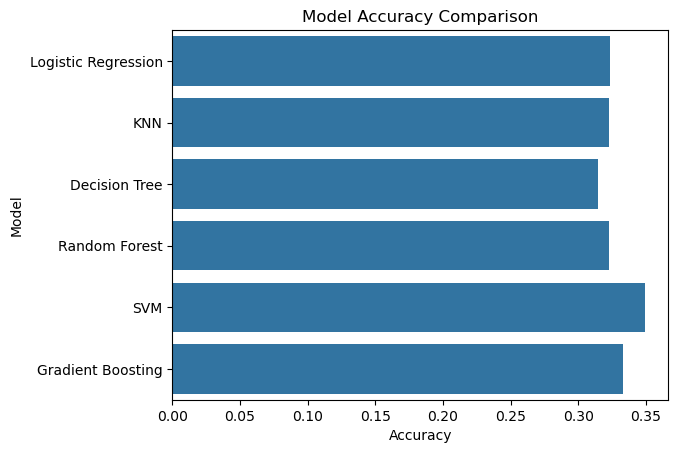

In [80]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Accuracy', y='Model', data=results_df)
plt.title("Model Accuracy Comparison")
plt.show()